# Rotation model

## Importing libraries

In [ ]:
import typing
import pathlib
import zipfile

import gdown
import tqdm
import IPython.display
import sklearn.model_selection
import torch
import torch.utils.data
import torch.nn
import torch.optim
import torchvision.io
import torchvision.transforms
import PIL.Image

## Uploading data

In [ ]:
file_id = '1k3mz_ZejJk9vNlGu61RHAVWQHmCi9tq9'
url = f'https://drive.google.com/uc?id={file_id}'
dataset_zip = pathlib.Path('dataset.zip')
gdown.download(url, dataset_zip.name)

zipfile.ZipFile(dataset_zip, 'r').extractall('.')
!rm '{dataset_zip}'

Downloading...
From (original): https://drive.google.com/uc?id=1k3mz_ZejJk9vNlGu61RHAVWQHmCi9tq9
From (redirected): https://drive.google.com/uc?id=1k3mz_ZejJk9vNlGu61RHAVWQHmCi9tq9&confirm=t&uuid=212064d5-8843-4d4f-b9e7-10d0e381a9cd
To: /content/dataset.zip
100%|██████████| 50.5M/50.5M [00:01<00:00, 46.6MB/s]


In [ ]:
path_to_data = pathlib.Path(dataset_zip.stem)

In [ ]:
img_paths: list[pathlib.Path] = []
for path_to_image in path_to_data.rglob('*.png'):
  img_paths.append(path_to_image)

In [ ]:
img_paths.sort(key=lambda img: img.name)

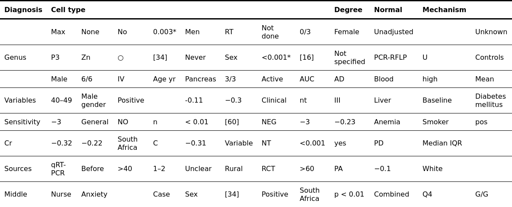

In [ ]:
IPython.display.display(IPython.display.Image(img_paths[0]))

## Data separation

In [ ]:
class RotatedImagesDataset(torch.utils.data.Dataset):
  def __init__(
    self,
    img_labels: list[int],
    img_paths: list[pathlib.Path],
    transform=None,
    target_transform=None,
  ) -> None:
    self.img_labels = img_labels
    self.img_paths = img_paths
    self.transform = transform
    self.target_transform = target_transform

  def __len__(self):
    return len(self.img_labels)

  def __getitem__(self, idx: int) -> tuple[torch.FloatTensor, int]:
    image = PIL.Image.open(self.img_paths[idx])
    label = self.img_labels[idx]
    if self.transform:
        image = self.transform(image)

    if self.target_transform:
        label = self.target_transform(label)

    return image, label

In [ ]:
img_labels = [i % 4 for i in range(len(img_paths))]

In [ ]:
number_train_img = int(len(img_paths) * 0.67)
number_train_img

670

In [ ]:
transform = torchvision.transforms.Compose([
    torchvision.transforms.Grayscale(num_output_channels=1),
    torchvision.transforms.Resize((256, 256)),
    torchvision.transforms.ToTensor(),
])

In [ ]:
target_transform = torchvision.transforms.Lambda(
    lambda y: torch.nn.functional.one_hot(
      torch.tensor(y),
      num_classes=4,
    ).float()
)

In [ ]:
train_dataset = RotatedImagesDataset(
    img_labels[:number_train_img],
    img_paths[:number_train_img],
    transform=transform,
    target_transform=target_transform,
)
val_dataset = RotatedImagesDataset(
    img_labels[number_train_img:],
    img_paths[number_train_img:],
    transform=transform,
    target_transform=target_transform,
)

In [ ]:
train_dataset[0][0].shape

torch.Size([1, 256, 256])

In [ ]:
train_dataset[0]

(tensor([[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.4941, 0.4941, 0.4941,  ..., 0.4941, 0.4941, 0.4941],
          [0.8549, 0.8549, 0.8549,  ..., 0.8549, 0.8549, 0.8549],
          ...,
          [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
          [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
          [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000]]]),
 tensor([1., 0., 0., 0.]))

In [ ]:
BATCH_SIZE: int = 64

In [ ]:
train_dataloader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
)
val_dataloader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

## Creating a model

In [ ]:
class RotationModel(torch.nn.Module):
  def __init__(self, number_rotation: int):
    super().__init__()
    self.number_rotation = number_rotation
    self.layers = torch.nn.Sequential(
        torch.nn.Conv2d(1, self.number_rotation, 7),
        torch.nn.ReLU(),
        torch.nn.BatchNorm2d(self.number_rotation),

        torch.nn.Conv2d(self.number_rotation, self.number_rotation, 3),
        torch.nn.ReLU(),
        torch.nn.BatchNorm2d(self.number_rotation),

        torch.nn.Conv2d(self.number_rotation, self.number_rotation, 3),
        torch.nn.ReLU(),
        torch.nn.BatchNorm2d(self.number_rotation),

        torch.nn.Conv2d(self.number_rotation, self.number_rotation, 3),
        torch.nn.ReLU(),
        torch.nn.BatchNorm2d(self.number_rotation),

        torch.nn.Conv2d(self.number_rotation, self.number_rotation, 3),
        torch.nn.ReLU(),
        torch.nn.BatchNorm2d(self.number_rotation),

        torch.nn.AdaptiveAvgPool2d(1),
        torch.nn.Flatten(),
        torch.nn.Linear(self.number_rotation, self.number_rotation),
        torch.nn.BatchNorm1d(self.number_rotation),
        torch.nn.Softmax(dim=1),
    )

  def forward(self, x: torch.FloatTensor) -> float:
    return self.layers(x)

In [ ]:
model = RotationModel(4)

## Model training

In [ ]:
loss_fn = torch.nn.CrossEntropyLoss()
optim = torch.optim.SGD(model.parameters(), lr=0.1, momentum=0.9)

In [ ]:
NUMBER_EPOCHS: int = 5

In [ ]:
for epoch in range(1, NUMBER_EPOCHS + 1):
  print('=' * 100)
  print(f'Epoch: {epoch}')
  print('Training...')
  for X, y in tqdm.tqdm(train_dataloader):
    optim.zero_grad()
    loss_fn(model(X), y).backward()
    optim.step()

  print('Evaluation...')
  sum_loss: float = 0
  for X, y in tqdm.tqdm(val_dataloader):
    with torch.no_grad():
      sum_loss += loss_fn(model(X), y)

  avg_loss = sum_loss / len(val_dataset)
  print(f'Avg val loss: {avg_loss:.4f}\n')

Epoch: 1
Training...


100%|██████████| 11/11 [01:04<00:00,  5.83s/it]


Evaluation...


100%|██████████| 6/6 [00:10<00:00,  1.74s/it]


Avg val loss: 0.0252

Epoch: 2
Training...


...

Avg val loss: 0.0228

Epoch: 5
Training...


100%|██████████| 11/11 [01:01<00:00,  5.62s/it]


Evaluation...


100%|██████████| 6/6 [00:09<00:00,  1.53s/it]

Avg val loss: 0.0224



## Save result

In [ ]:
torch.save(model.state_dict(), 'model_weights.pth')

In [ ]:
loaded_model = RotationModel(4)
loaded_model.load_state_dict(torch.load('model_weights.pth', weights_only=True))
loaded_model.eval()

RotationModel(
  (layers): Sequential(
    (0): Conv2d(1, 4, kernel_size=(7, 7), stride=(1, 1))
    (1): ReLU()
    (2): BatchNorm2d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Conv2d(4, 4, kernel_size=(3, 3), stride=(1, 1))
    (4): ReLU()
    (5): BatchNorm2d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): Conv2d(4, 4, kernel_size=(3, 3), stride=(1, 1))
    (7): ReLU()
    (8): BatchNorm2d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): Conv2d(4, 4, kernel_size=(3, 3), stride=(1, 1))
    (10): ReLU()
    (11): BatchNorm2d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): Conv2d(4, 4, kernel_size=(3, 3), stride=(1, 1))
    (13): ReLU()
    (14): BatchNorm2d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (15): AdaptiveAvgPool2d(output_size=1)
    (16): Flatten(start_dim=1, end_dim=-1)
    (17): Linear(in_features=4, out_features=4, bias=True)
    (1

In [ ]:
loaded_model(X)

tensor([[0.2773, 0.3137, 0.2141, 0.1950],
        [0.3872, 0.0653, 0.4387, 0.1088],
        [0.5979, 0.0557, 0.3143, 0.0321],
        [0.5262, 0.0295, 0.4079, 0.0364],
        [0.1380, 0.1595, 0.2412, 0.4613],
        [0.0759, 0.2394, 0.1154, 0.5694],
        [0.5853, 0.0262, 0.3660, 0.0225],
        [0.3673, 0.3409, 0.1907, 0.1011],
        [0.4020, 0.2421, 0.2478, 0.1081],
        [0.6256, 0.0166, 0.3451, 0.0127]], grad_fn=<SoftmaxBackward0>)